In [1]:
import numpy as np
import pandas as pd

from utils import validate, package_run_data, package_calib_data, circdist, circmedian
from tqdm import tqdm
import pickle

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import arviz as az
import colorsys

#NP set random seed
np.random.seed(42)

az.style.use("arviz-docgrid")

In [2]:
# Math imports
import math
from functools import partial
from itertools import count
import numpy as np
from scipy.stats import norm, poisson, expon, uniform, binom, beta, halfnorm
import jax.numpy as jnp
import jax.random as jr
from jax import vmap
import optax

from dynamax.hidden_markov_model import GaussianHMM, DiagonalGaussianHMM, LinearRegressionHMM
from dynamax.utils.utils import find_permutation

In [3]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


## Loading data

In [4]:
experiment_orientations = [159, 123, 87, 51, 15]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

In [5]:
# Allow negative angles in calibration
c_table, med, std, ctimetable = package_calib_data(do_clip=False)
r_table, (x, y, d, r, e) = package_run_data(med, std, do_clip=False, do_noise_thresh=False)

Loading data: 100%|██████████| 288/288 [00:00<00:00, 296.50it/s]


## Formatting data for models

In [6]:
xaxis = np.arange(-250, 750, 1) * (1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
(start_idx, end_idx)

(191, 430)

In [7]:
# our frmes of intrest are only
er = e[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

# ds
ds = d[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

er[np.isnan(er)] = 90
ds[np.isnan(ds)] = 0

er.shape, np.isnan(er).any(), ds.shape, np.isnan(ds).any()

((34560, 239), False, (34560, 239), False)

In [8]:
ds.max(), ds.min(), er.max(), er.min()

(1.0, 0.0, 179.99498302460654, 0.0)

In [9]:
# min max scale err
er = er / 180

train_emissions = jnp.array(np.stack([ds, er], axis=-1))
train_emissions.shape

(34560, 239, 2)

## GLOBAL MODEL

### Subset Cross val for optimal states

In [198]:
crossval_subset = np.random.choice(np.arange(0, len(train_emissions)), 400, replace=False)
crossval_emissions = train_emissions[crossval_subset]

# crossval_emissions = crossval_emissions[:,::2,:]
crossval_emissions.shape

(400, 239, 2)

In [199]:
num_train_batches = crossval_emissions.shape[0]
emission_dim = 2

In [206]:
def cross_validate_model(model, key, num_iters=10):
    # Initialize the parameters using K-Means on the full training set
    params, props = model.initialize(key=key, method="kmeans", emissions=crossval_emissions)
    
    # Split the training data into folds.
    folds = jnp.stack([
        jnp.concatenate([crossval_emissions[:i], crossval_emissions[i+1:]])
        for i in range(num_train_batches)
    ])
    
    # def _fit_fold(y_train, y_val):
    #     fit_params, train_lps = model.fit_sgd(
    #         params, props, y_train,
    #         num_epochs = 100, 
    #         optimizer = optax.adam(1e-4), 
    #         shuffle = True, 
    #         batch_size = 8,
    #     )
    #     return model.marginal_log_prob(fit_params, y_val)
    
    def _fit_fold(y_train, y_val):
        fit_params, train_lps = model.fit_em(params, props, y_train, num_iters=num_iters)
        return model.marginal_log_prob(fit_params, y_val)

    val_lls = vmap(_fit_fold)(folds, crossval_emissions)
    return val_lls.mean(), val_lls

In [207]:
# Make a range of Gaussian HMMs
all_num_states = list(range(2, 10))
test_hmms = [GaussianHMM(num_states, emission_dim, transition_matrix_stickiness=10.) 
          for num_states in all_num_states]
results = []
for test_hmm in test_hmms:
    # print(f"fitting model with {test_hmm.num_states} states")
    results.append(cross_validate_model(test_hmm, jr.PRNGKey(0)))
    
avg_val_lls, all_val_lls = tuple(zip(*results))

## Viz performanc

In [208]:
# # Calculating aic and bic

# # For a discrete-time hidden Markov model, AIC and BIC are as follows (MacDonald & Zucchini (2009, Paragraph 6.1 and A.2.3)):

# # AIC = -2 logL + 2p
# # BIC = -2 logL + p log(T),

# # where T indicates the length/size of the observation time-series and p denotes the number of independent parameters of the model. 
# # In case of a HMM as provided by this package, where k and m are defined as in the arguments above, p can be calculated as follows:

# # p = m^2 + km - 1.

# m = number of states in the Markov chain of the model.
# k = single numeric value representing the number of parameters of the underlying distribution of the observation process (e.g. k=2 for the normal distribution (mean and standard deviation)).
# # https://rdrr.io/cran/HMMpa/man/AIC_HMM.html

# So for a Gaussian HMM, the number of parameters is given by:
# k=D+(D(D+1))/2

def calc_aic_bic(n_state, log_likelihood, emission_dim, T):

    m = n_state
    k = emission_dim + (emission_dim*(emission_dim+1))/2

    p = m**2 + k*m - 1

    aic = -2*log_likelihood + 2*p
    bic = -2*log_likelihood + p*jnp.log(T)

    return aic, bic

In [209]:
aic, bic = [], []
for i, (n_state, ll) in enumerate(zip(all_num_states, all_val_lls)):
    T = crossval_emissions.shape[1] # 239
    a, b = calc_aic_bic(n_state, ll, emission_dim, T)
    # print(f"Model with {n_state} states has AIC: {aic} and BIC: {bic}")
    aic.append(a)
    bic.append(b)

aic, bic = np.array(aic), np.array(bic)

/tmp/ipykernel_337527/1927100037.py:21: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=ax.lines + ax2.lines, loc='upper right')


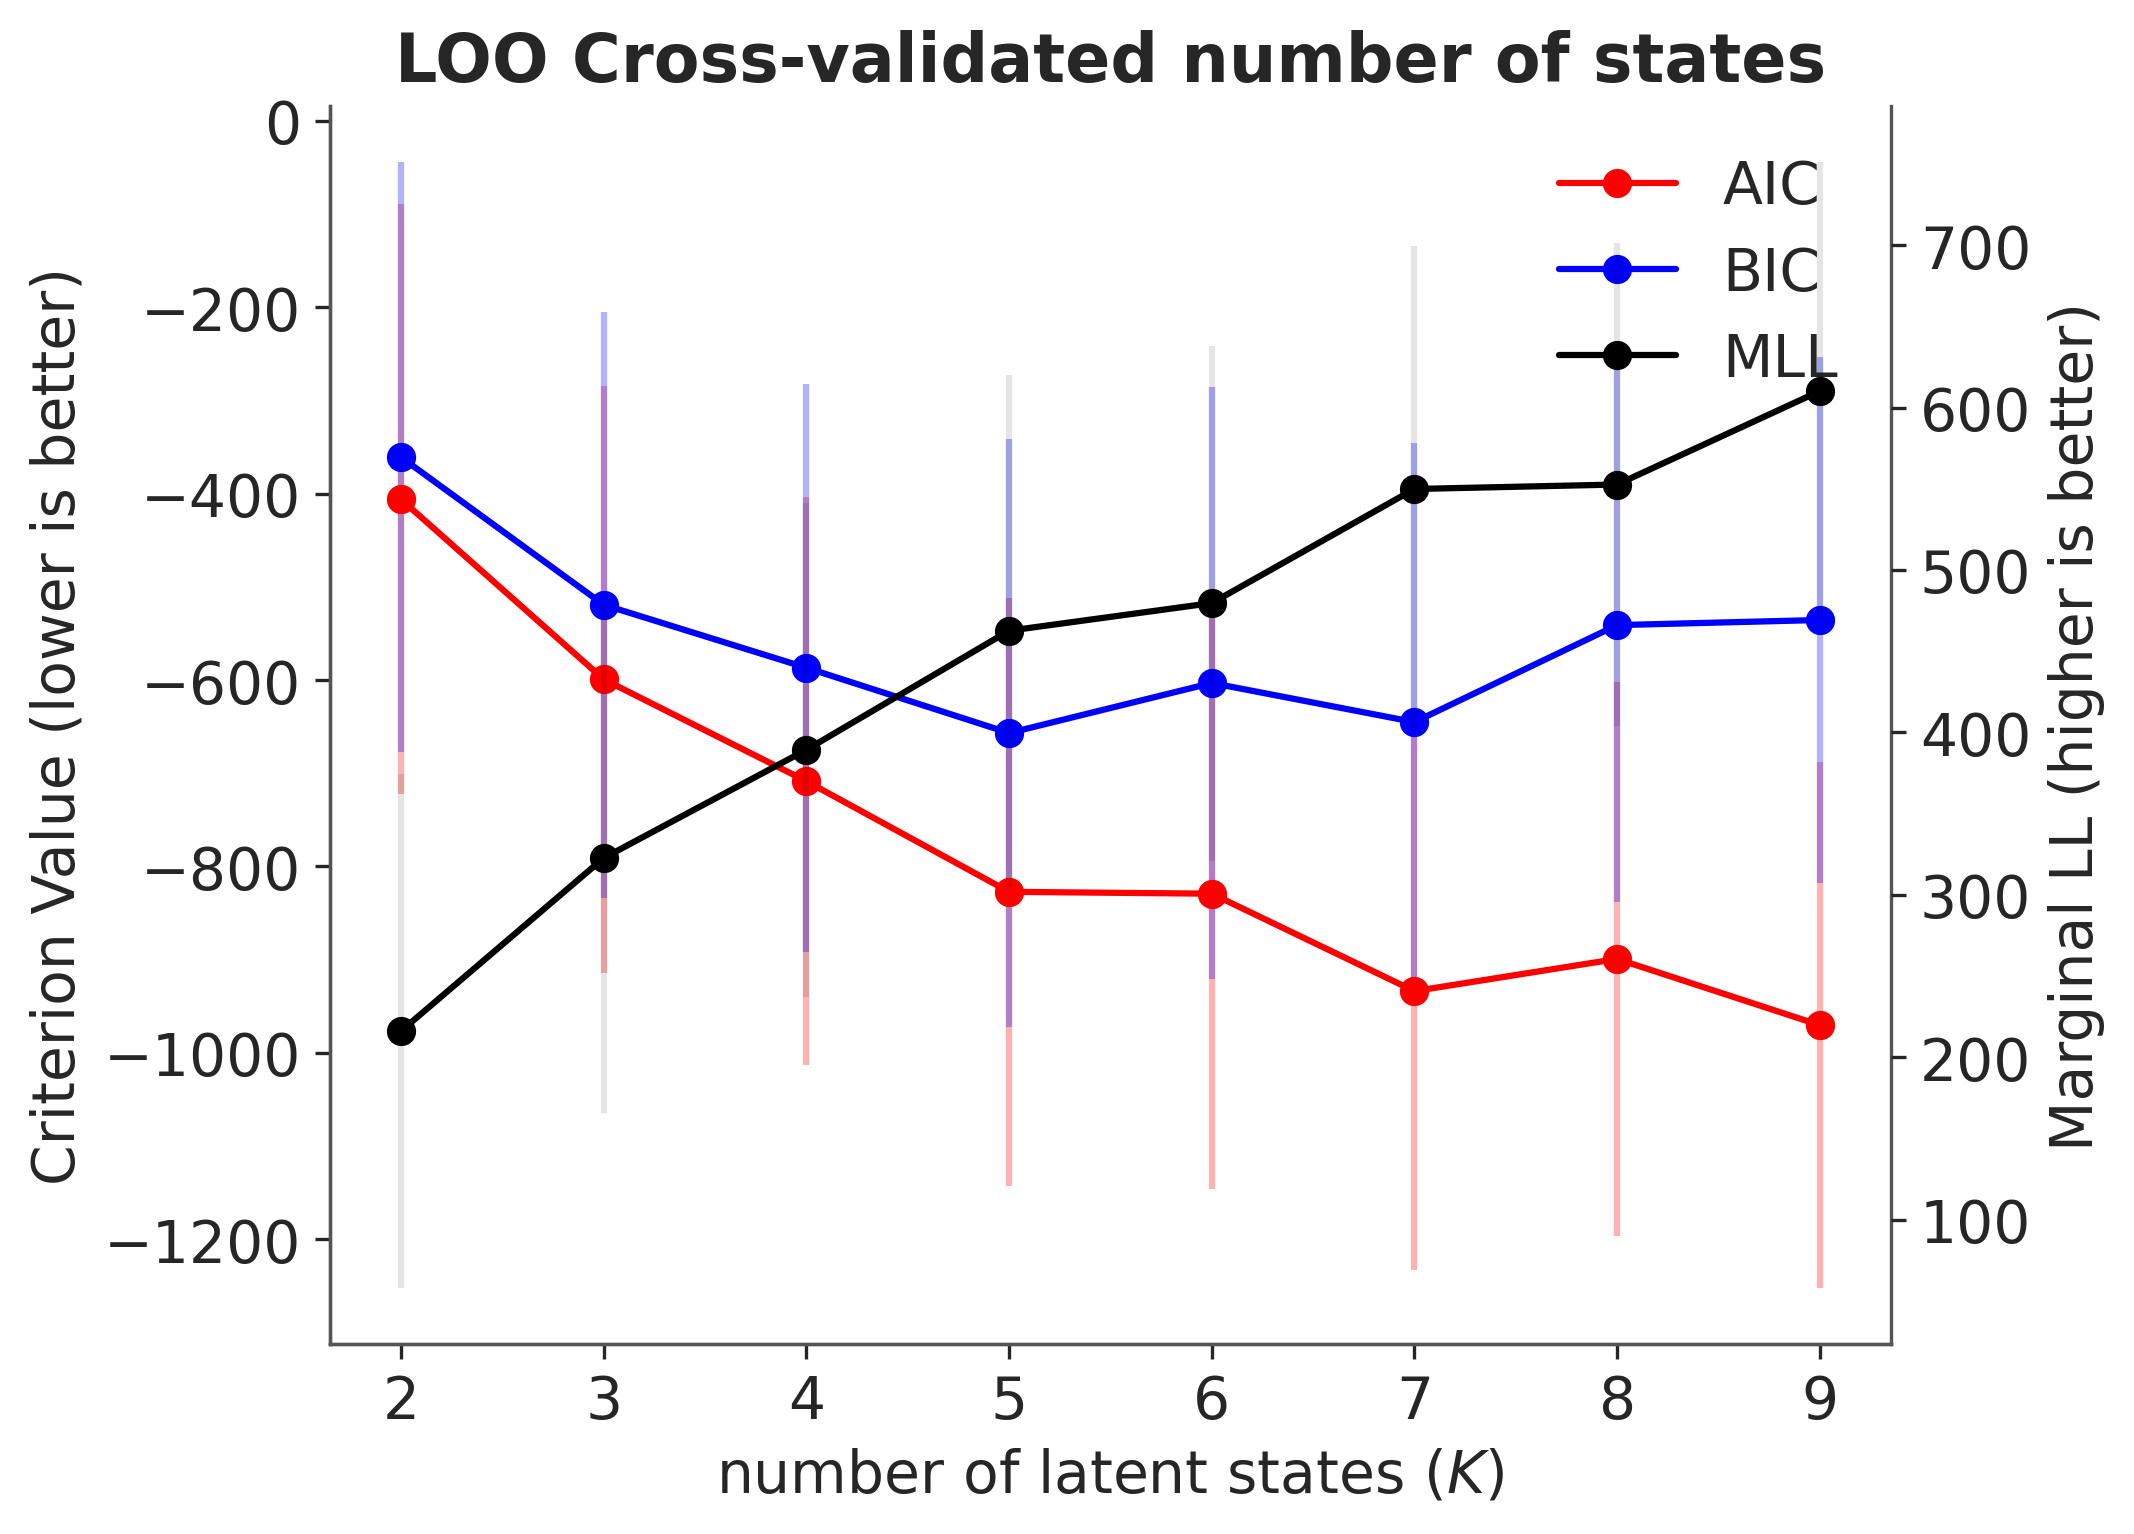

In [210]:
fig, ax = plt.subplots(figsize=(7,5), dpi=300)

for k, per_fold_val_lls, iaic, ibic in zip(all_num_states, all_val_lls, aic, bic):
    ax.errorbar(k, jnp.mean(iaic), yerr=jnp.std(iaic), fmt='o', color='r', alpha=0.3)
    ax.errorbar(k, jnp.mean(ibic), yerr=jnp.std(ibic), fmt='o', color='b', alpha=0.3)

ln1 = ax.plot(all_num_states, aic.mean(axis=1), '-ro', label="AIC")
ln2 = ax.plot(all_num_states, bic.mean(axis=1), '-bo', label="BIC")


ax2 = ax.twinx()


for k, per_fold_val_lls, iaic, ibic in zip(all_num_states, all_val_lls, aic, bic):
    # plt.plot(k * jnp.ones_like(per_fold_val_lls), per_fold_val_lls, '.k', alpha=0.1)
    # use this to make error bars isntead
    ax2.errorbar(k, jnp.mean(per_fold_val_lls), yerr=jnp.std(per_fold_val_lls), fmt='o', color='k', alpha=0.1)

ln3 = ax2.plot(all_num_states, avg_val_lls, '-ko', label="MLL")

ax.legend(handles=ax.lines + ax2.lines, loc='upper right')

ax.set_xticks(all_num_states)
ax.set_xlabel("number of latent states ($K$)")
ax.set_title("LOO Cross-validated number of states")
ax.set_ylabel("Criterion Value (lower is better)")
ax2.set_ylabel("Marginal LL (higher is better)")
#enable right side border
ax.spines['right'].set_visible(True)
ax.grid(False)
ax2.grid(False)
plt.show()

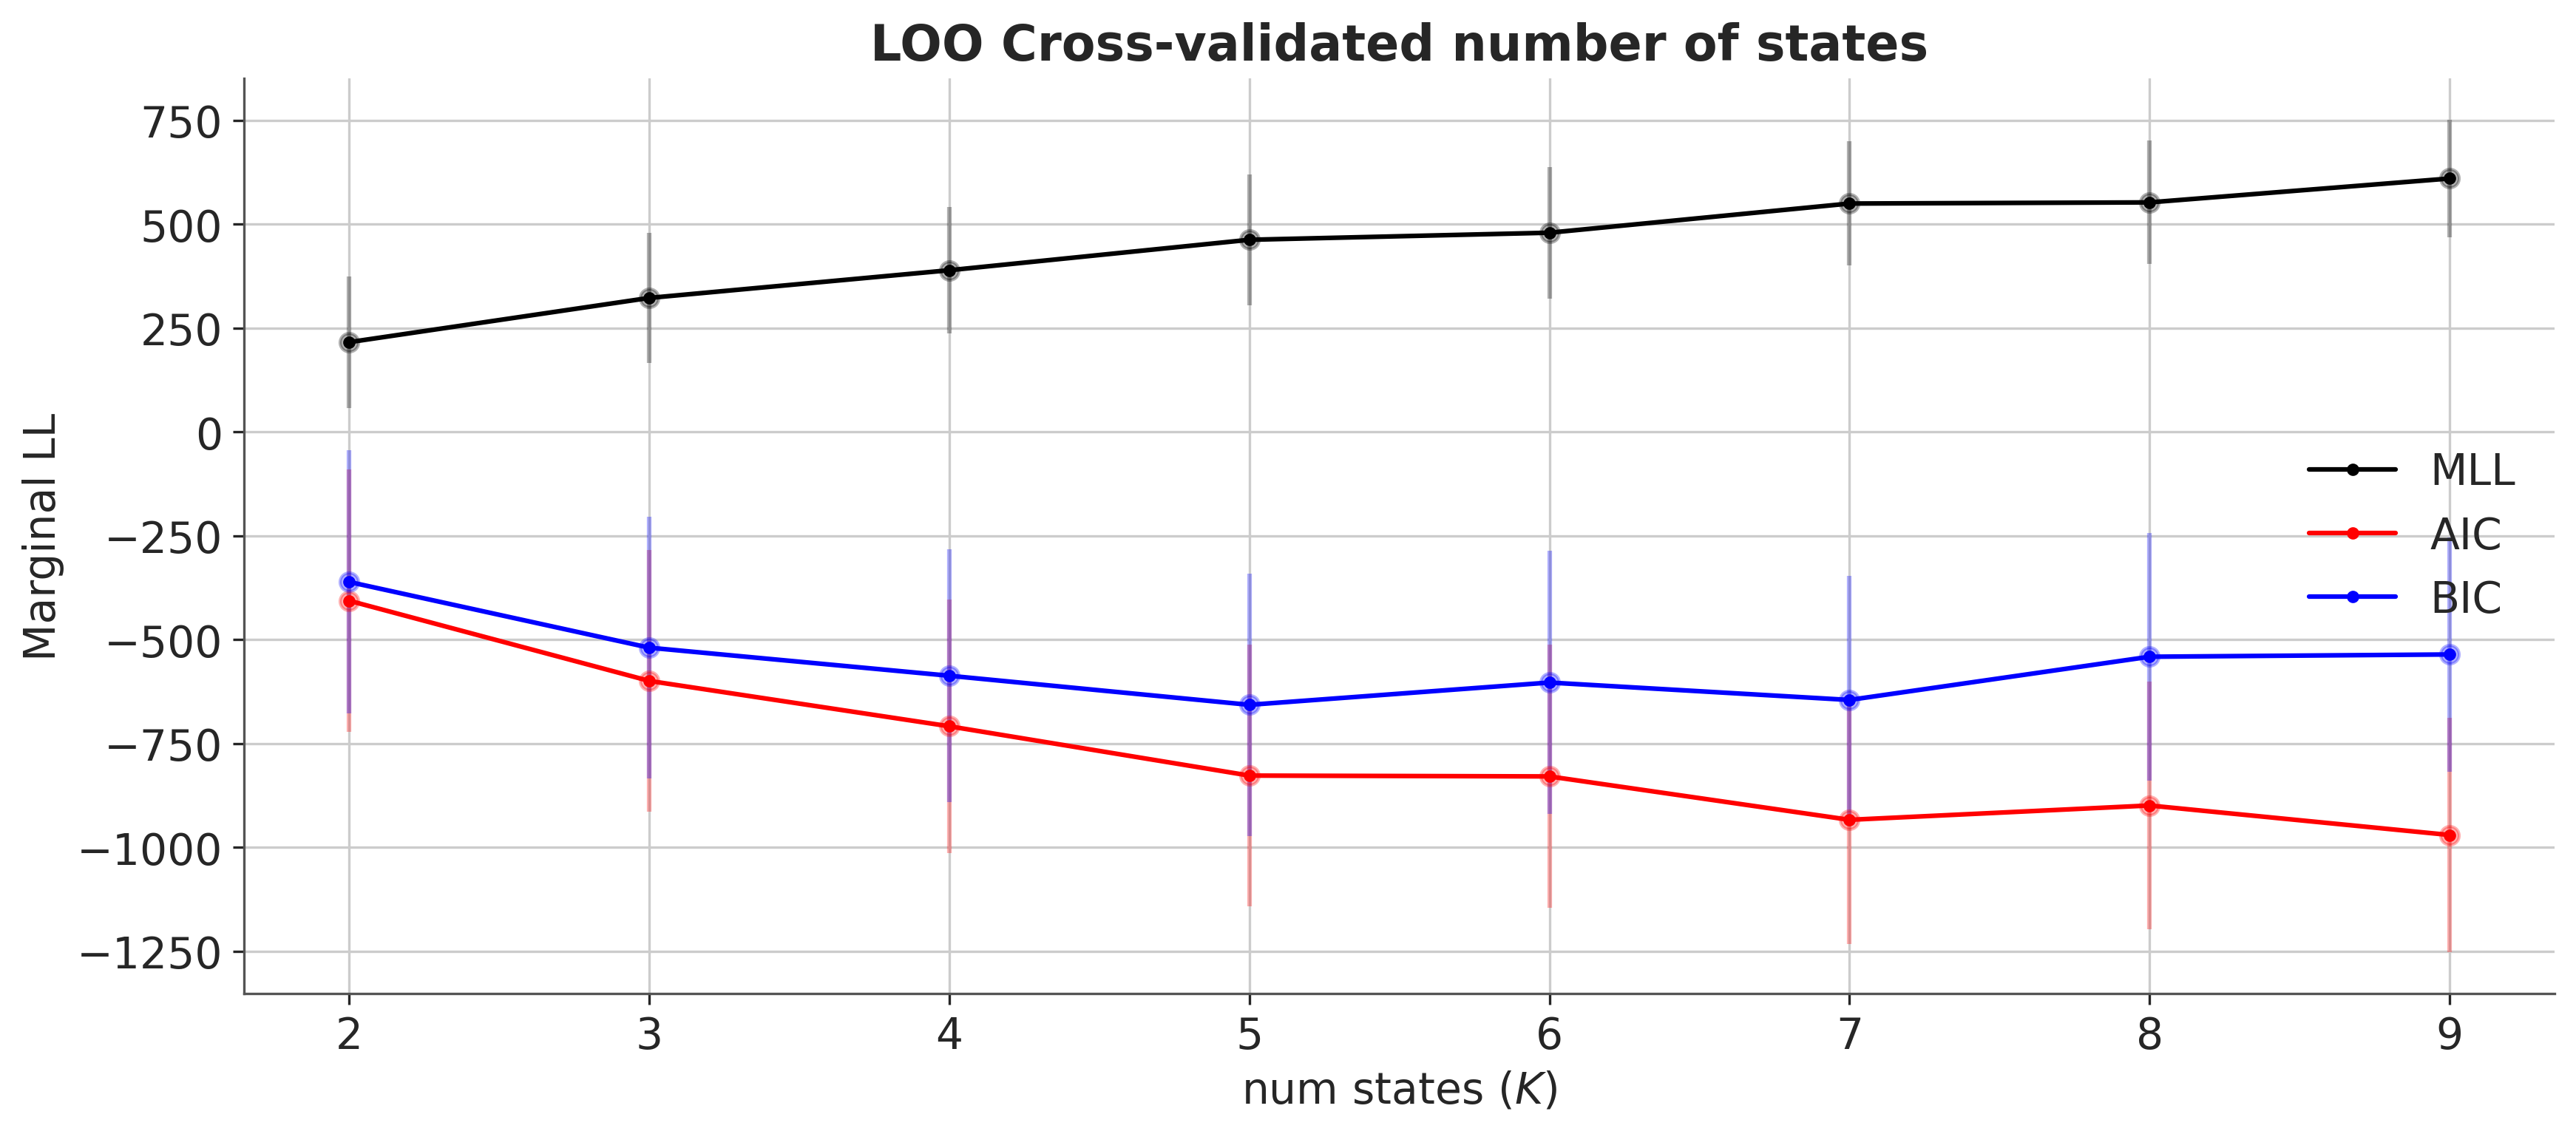

In [211]:


plt.figure()
for k, per_fold_val_lls, iaic, ibic in zip(all_num_states, all_val_lls, aic, bic):
    # plt.plot(k * jnp.ones_like(per_fold_val_lls), per_fold_val_lls, '.k', alpha=0.1)
    # use this to make error bars isntead
    plt.errorbar(k, jnp.mean(per_fold_val_lls), yerr=jnp.std(per_fold_val_lls), fmt='o', color='k', alpha=0.3)
    plt.errorbar(k, jnp.mean(iaic), yerr=jnp.std(iaic), fmt='o', color='r', alpha=0.3)
    plt.errorbar(k, jnp.mean(ibic), yerr=jnp.std(ibic), fmt='o', color='b', alpha=0.3)

plt.plot(all_num_states, avg_val_lls, '-k.', label="MLL")
plt.plot(all_num_states, aic.mean(axis=1), '-r.', label="AIC")
plt.plot(all_num_states, bic.mean(axis=1), '-b.', label="BIC")
plt.xlabel("num states ($K$)")
plt.ylabel("Marginal LL")
plt.title("LOO Cross-validated number of states")
plt.legend( loc='center right')
plt.show()

### Global full train 2 states model

In [44]:
# Initialize the parameters using K-Means on the full training set
key = jr.PRNGKey(0)
t_hmm = GaussianHMM(num_states=2, emission_dim=2, transition_matrix_stickiness=10.)
params, props = t_hmm.initialize(key=key, method="kmeans", emissions=train_emissions)
# params, lps = t_hmm.fit_sgd(
#     params, props, train_emissions,
#     num_epochs = 100, 
#     optimizer = optax.adam(1e-4), 
#     shuffle = True, 
#     batch_size = 8,
# )
params, lps = t_hmm.fit_em(params, props, train_emissions, num_iters=10)

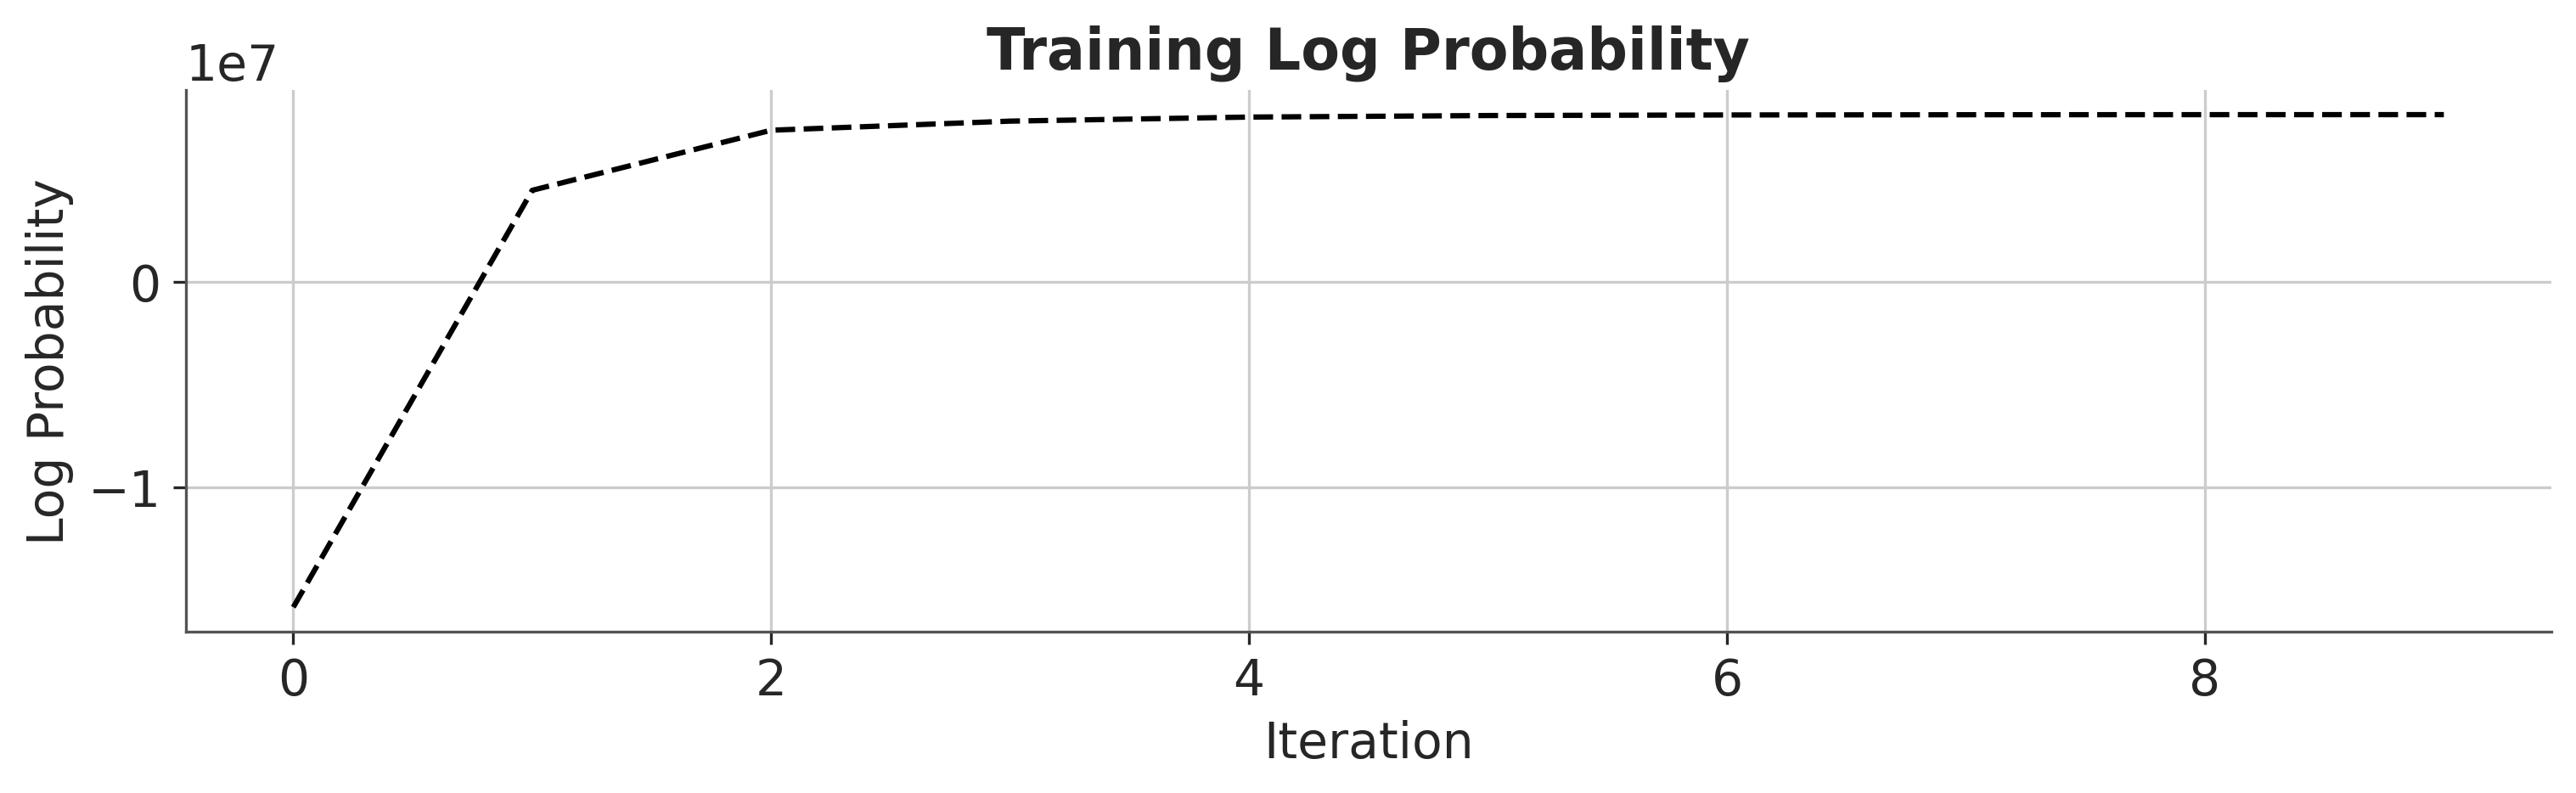

In [45]:
plt.figure(figsize=(10, 3))
plt.plot(lps, "k--")
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Training Log Probability")
plt.show()

In [19]:
# pickle the params\
# with open("global_init_params_2_states.pkl", "wb") as f:
#     pickle.dump(params, f)

In [22]:
# with open("hmm_caches/global_init_params_2_states.pkl", "rb") as f:
#     params = pickle.load(f)

In [46]:
params.transitions

ParamsStandardHMMTransitions(transition_matrix=Array([[0.9944212 , 0.00557886],
       [0.00869768, 0.9913023 ]], dtype=float32))

In [51]:
params.emissions

ParamsGaussianHMMEmissions(means=Array([[0.08612324, 0.36370203],
       [0.752349  , 0.23704416]], dtype=float32), covs=Array([[[ 0.00288843,  0.0008412 ],
        [ 0.0008412 ,  0.06508461]],

       [[ 0.07615882, -0.00311981],
        [-0.00311981,  0.04871779]]], dtype=float32))

In [52]:
params.initial

ParamsStandardHMMInitialState(probs=Array([0.9680262 , 0.03197376], dtype=float32))